In [ ]:
#DEFINIZIONE MODELLO
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLPModel(nn.Module):
    def __init__(self):
        super().__init__()
        input_dim = 17
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.output_layer = nn.Linear(64, 7)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        logit = self.output_layer(x)  
        return logit

## CENTRALIZED LEARNING

In [ ]:
import functools
import os
import numpy as np

from gossiplearning.config import Config
from utils.model_creators import create_MLP
from utils.multiprocessing_test import run_in_parallel

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import json
from pathlib import Path

from utils.centralized_training import train_centralized_model

with open("TON_IoT_config.json", "r") as f:
    config = json.load(f)

config = Config.model_validate(config)

In [ ]:
simulation_number = 0
num_nodes = 10
k = 3
alpha = 1

#timesteps = 4
dataset_path = Path(f"data/datasets/TON_IoT_{num_nodes}n_{k}k")

### Testing 

In [ ]:
import torch
from utils.data import load_npz_data
import numpy as np

#simulation_number = 0

#4inTestBalanced
model = torch.load(f"data/datasets/TON_IoT_{num_nodes}n_{k}k/{simulation_number}/4inTestBalancedAlpha0{alpha}/models/centralized.pt")
datasets = tuple([load_npz_data(f"data/datasets/TON_IoT_{num_nodes}n_{k}k/{simulation_number}/4inTestBalancedAlpha0{alpha}/node_{i}.npz") for i in range(10)])

X = np.concatenate([d[4] for d in datasets])
Y = np.concatenate([d[5] for d in datasets])

In [ ]:
from pathlib import Path
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from utils.metrics import compute_metrics

loaded_model = MLPModel()
loaded_model.load_state_dict(model)

x_tensor = torch.tensor(X.astype("float32"), dtype=torch.float32)
y_tensor = torch.tensor(Y, dtype=torch.long)
history_centr = []

loaded_model.eval()
with torch.no_grad():
    logits = loaded_model(x_tensor)              
    y_pred = torch.argmax(logits, dim=1)         
    correct = (y_pred == y_tensor).sum().item()
    accuracy_centr = correct / len(y_tensor)

print("Accuracy:", accuracy_centr)
predictions_centr = y_pred.numpy()
true_centr = y_tensor.numpy()
centr_metrics = compute_metrics(true_centr, predictions_centr)
history_centr = {
    "accuracy": centr_metrics.acc,
    "precision_macro": centr_metrics.prec,
    "recall_macro": centr_metrics.rec,
    "f1_macro": centr_metrics.f1,
    "f1_weighted": centr_metrics.f1_weighted
}
probs_centr = torch.softmax(logits, dim=1)

print("X: ", x_tensor.shape)
print("Y: ", y_tensor.shape)

path_folder = Path(f"data/datasets/TON_IoT_{num_nodes}n_{k}k/{simulation_number}/4inTestBalancedAlpha0{alpha}/models/")
path_folder.mkdir(parents=True, exist_ok=True)

file_path = path_folder / "report_accuracy.json"
with open(file_path, "w") as outfile:
    json.dump([history_centr], outfile, indent=1)

In [ ]:
# Appending
filecentr = open("f1centr.txt", "a")
filecentr.write(str(centr_metrics.f1))
filecentr.write("\n")
filecentr.close()

## GOSSIP LEARNING

In [ ]:
from gossiplearning.config import Config
from utils.model_creators import create_MLP
from pathlib import Path
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from utils.data import load_npz_data
#simulation_number = 0
#num_nodes = 10
#k = 3
#alpha = 5

#4inTestBalanced
#del datasets, X, Y
model = tuple([torch.load(f"experiments/TON_IoT/{num_nodes}nTest{k}kAlpha0{alpha}SecondaSim/{simulation_number}/models/{i}.pth") for i in range(num_nodes)])
datasets = []
datasets = tuple([load_npz_data(f"data/datasets/TON_IoT_{num_nodes}n_{k}k/{simulation_number}/4inTestBalancedAlpha0{alpha}/node_{i}.npz") for i in range(num_nodes)])

X = np.concatenate([d[4] for d in datasets])
Y = np.concatenate([d[5] for d in datasets])
n_samples = 3500000  
idx = np.random.choice(len(X), size=n_samples, replace=False)

In [ ]:
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from utils.metrics import compute_metrics
import seaborn as sns


x_tensor = torch.tensor(X[idx].astype("float32"), dtype=torch.float32)
y_tensor = torch.tensor(Y[idx], dtype=torch.long)
num_classes = 7
error_matrix = np.zeros((num_nodes, num_classes))

print("X: ", x_tensor.shape)
print("Y: ", y_tensor.shape)
accuracy_gossip_list = []
history = []

for i in range(num_nodes):
    print("Initializing model from node ", i)
    loaded_model = MLPModel()
    loaded_model.load_state_dict(model[i])

    loaded_model.eval()
    with torch.no_grad():
        logits = loaded_model(x_tensor)              
        y_pred = torch.argmax(logits, dim=1)         
        correct = (y_pred == y_tensor).sum().item()
        accuracy_gossip = correct / len(y_tensor)

    print("Node: ", str(i))
    print("Accuracy:", str(accuracy_gossip), "\n")
    accuracy_gossip_list.append(accuracy_gossip)
    probs = torch.softmax(logits, dim=1)

    predictions_gos = y_pred.numpy()
    true_pred = y_tensor.numpy()
    metrics = compute_metrics(true_pred, predictions_gos)
    dict_history = {
        "Node": str(i),
        "accuracy": metrics.acc,
        "precision_macro": metrics.prec,
        "recall_macro": metrics.rec,
        "f1_macro": metrics.f1,
        "f1_weighted": metrics.f1_weighted
    }
    history.append(dict_history)
    target_names = [str(c) for c in np.unique(true_pred)]
    report = classification_report(true_pred, 
                                        predictions_gos, 
                                        labels=[0,1,2,3,4,5,6], 
                                        target_names=target_names, zero_division=0,
                                        output_dict=True
                                        )

    cm = confusion_matrix(true_pred, predictions_gos, labels=range(7))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                        xticklabels=range(7), yticklabels=range(7))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    path_folder = Path(f"experiments/TON_IoT/{num_nodes}nTest{k}kAlpha0{alpha}SecondaSim") / f"{simulation_number}" / "testing_unified"
    path_folder.mkdir(parents=True, exist_ok=True)
    plt.savefig(path_folder/ f"matrix_node{i}.png")
    plt.close()

    file_path = path_folder / "report_accuracy.json"
    if not file_path.exists():
        with open(file_path, "w") as outfile:
            json.dump(dict_history, outfile, indent=1)
    else:
        with open(file_path, "r+") as outfile:
            file_data = json.load(outfile)
            if not isinstance(file_data, list):
                file_data = [file_data]
            file_data.append(dict_history)
            outfile.seek(0)
            json.dump(file_data, outfile, indent=1)
        outfile.close
    with open(path_folder/ f"report_node_{i}.json", "w") as outfiler:
                json.dump(report, outfiler, indent=3)
    outfiler.close
    for c in range(num_classes):
        mask = (true_pred == c)
        errors = np.sum(predictions_gos[mask] != c)
        total = np.sum(mask)
        error_matrix[i, c] = errors / total if total > 0 else 0.0

# Plot
x = np.arange(num_nodes)  # nodi
width = 0.1               # larghezza delle barre
plt.figure(figsize=(25,10))

for c in range(num_classes):
    plt.bar(x + c*width, error_matrix[:, c], width, label=f"Classe {c}")

plt.xlabel("Nodo")
plt.ylabel("Errore (%)")
plt.title(f"Percentuale di errore con α = 0.{alpha}")
plt.xticks(x + (num_classes/2 - 0.5)*width, [f"Nodo {i}" for i in range(num_nodes)])
plt.legend()
plt.tight_layout()
plt.savefig(path_folder/ f"istogramma_err.png")
plt.show()


In [ ]:
import matplotlib.pyplot as plt

xs = [x for x in range(len(history))]

all_acc, all_prec, all_rec, all_f1, all_f1_w = [], [], [], [], []
for i in range(len(history)):
    all_acc.append(history[i].get('accuracy'))
    all_prec.append(history[i].get('precision_macro'))
    all_rec.append(history[i].get('recall_macro'))
    all_f1.append(history[i].get('f1_macro'))
    all_f1_w.append(history[i].get('f1_weighted'))

plt.figure(figsize=(15,12))
plt.xlabel("Nodi")
plt.ylabel("Value %")
plt.xticks(xs)
#plt.plot(xs, accuracy_gossip_list)
plt.plot(
    all_acc,
    label="Gossip Accuracy",
    color="royalblue",
    linewidth=2,
)
plt.plot(
    all_prec,
    label="Gossip Precision",
    color="limegreen",
    linewidth=2,
)
plt.plot(
    all_rec,
    label="Gossip Recall",
    color="darkviolet",
    linewidth=2,
)
plt.plot(
    all_f1,
    label="Gossip F1 Macro",
    color="crimson",
    linewidth=2,
)
plt.plot(
    all_f1_w,
    label="Gossip F1 Weighted",
    color="black",
    linewidth=2,
)

plt.legend()
plt.savefig(Path(path_folder) / "comparison_plot.jpg")
plt.show()
plt.close()

In [ ]:
import statistics
all_value_means = []
alphas = [0.1, 0.3, 0.5, 0.9]
#alphas = [3,5,7,9]

all_value_means.append(statistics.mean(all_acc))
all_value_means.append(statistics.mean(all_prec))
all_value_means.append(statistics.mean(all_rec))
all_value_means.append(statistics.mean(all_f1))
all_value_means.append(statistics.mean(all_f1_w))

print(all_value_means)

In [ ]:
# Appending
file1 = open("f1gossip.txt", "a")
file1.write(str(all_value_means[4]))
file1.write("\n") 
file1.close()

## LOCAL LEARNING

In [ ]:
from utils.single_node_training import train_single_nodes

"""simulation_number = 0
num_nodes = 10
k = 3
alpha = 5"""

with open("TON_IoT_config.json", "r") as f:
    config = json.load(f)

config = Config.model_validate(config)

dataset_path = Path(f"data/datasets/TON_IoT_{num_nodes}n_{k}k")

### Testing

In [ ]:
from pathlib import Path
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from utils.metrics import compute_metrics
import functools
import os

from gossiplearning.config import Config
from utils.model_creators import create_MLP
from utils.multiprocessing_test import run_in_parallel

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import json
from pathlib import Path
import torch
from utils.data import load_npz_data
import numpy as np

"""simulation_number = 0
num_nodes = 10
k = 3
alpha = 1"""

#4inTestBalanced
del datasets, X, Y
model = tuple([torch.load(f"data/datasets/TON_IoT_{num_nodes}n_{k}k/{simulation_number}/4inTestBalancedAlpha0{alpha}/models/node_{i}/single_node_{i}.pt") for i in range(num_nodes)])
datasets_loc = tuple([load_npz_data(f"data/datasets/TON_IoT_{num_nodes}n_{k}k/{simulation_number}/4inTestBalancedAlpha0{alpha}/node_{i}.npz") for i in range(num_nodes)])

X = np.concatenate([d[4] for d in datasets_loc])
Y = np.concatenate([d[5] for d in datasets_loc])

In [ ]:
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from utils.metrics import compute_metrics
import seaborn as sns

#np.random.shuffle(X)
#np.random.shuffle(Y)

x_tensor = torch.tensor(X[idx].astype("float32"), dtype=torch.float32)
y_tensor = torch.tensor(Y[idx], dtype=torch.long)
num_classes = 7
error_matrix = np.zeros((num_nodes, num_classes))

print("X: ", x_tensor.shape)
print("Y: ", y_tensor.shape)
accuracy_local_list = []
history = []

for i in range(num_nodes):
    print("Initializing model from node ", i)
    loaded_model = MLPModel()
    loaded_model.load_state_dict(model[i])

    loaded_model.eval()
    with torch.no_grad():
        logits = loaded_model(x_tensor)              
        y_pred = torch.argmax(logits, dim=1)         
        correct = (y_pred == y_tensor).sum().item()
        accuracy_local = correct / len(y_tensor)

    print("Node: ", str(i))
    print("Accuracy:", str(accuracy_local), "\n")
    accuracy_local_list.append(accuracy_local)
    probs = torch.softmax(logits, dim=1)

    predictions_loc = y_pred.numpy()
    true_pred = y_tensor.numpy()
    metrics = compute_metrics(true_pred, predictions_loc)
    dict_history = {
        "Node": str(i),
        "accuracy": metrics.acc,
        "precision_macro": metrics.prec,
        "recall_macro": metrics.rec,
        "f1_macro": metrics.f1,
        "f1_weighted": metrics.f1_weighted
        
    }
    history.append(dict_history)
    target_names = [str(c) for c in np.unique(true_pred)]
    report = classification_report(true_pred, 
                                        predictions_loc, 
                                        labels=[0,1,2,3,4,5,6], 
                                        target_names=target_names, zero_division=0,
                                        output_dict=True
                                        )

    cm = confusion_matrix(true_pred, predictions_loc, labels=range(7))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                        xticklabels=range(7), yticklabels=range(7))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    path_folder = Path(f"data/datasets/TON_IoT_{num_nodes}n_{k}k/{simulation_number}/4inTestBalancedAlpha0{alpha}/plots/testing_unified")
    path_folder.mkdir(parents=True, exist_ok=True)
    plt.savefig(path_folder/ f"matrix_node{i}.png")
    plt.close()

    file_path = path_folder / "report_accuracy.json"
    if not file_path.exists():
        with open(file_path, "w") as outfile:
            json.dump(dict_history, outfile, indent=1)
    else:
        with open(file_path, "r+") as outfile:
            file_data = json.load(outfile)
            if not isinstance(file_data, list):
                file_data = [file_data]
            file_data.append(dict_history)
            outfile.seek(0)
            json.dump(file_data, outfile, indent=1)
        outfile.close
    with open(path_folder/ f"report_node_{i}.json", "w") as outfiler:
                json.dump(report, outfiler, indent=3)
    outfiler.close
    for c in range(num_classes):
        mask = (true_pred == c)
        errors = np.sum(predictions_loc[mask] != c)
        total = np.sum(mask)
        error_matrix[i, c] = errors / total if total > 0 else 0.0

# Plot
x = np.arange(num_nodes)  # nodi
width = 0.1               # larghezza delle barre
plt.figure(figsize=(25,10))

for c in range(num_classes):
    plt.bar(x + c*width, error_matrix[:, c], width, label=f"Classe {c}")

plt.xlabel("Nodo")
plt.ylabel("Errore (%)")
plt.title(f"Percentuale di errore con α = 0.{alpha}")
plt.xticks(x + (num_classes/2 - 0.5)*width, [f"Nodo {i}" for i in range(num_nodes)])
plt.legend()
plt.tight_layout()
plt.savefig(path_folder/ f"istogramma_err.png")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

xs = [x for x in range(len(history))]

all_acc, all_prec, all_rec, all_f1, all_f1_w = [], [], [], [], []
for i in range(len(history)):
    all_acc.append(history[i].get('accuracy'))
    all_prec.append(history[i].get('precision_macro'))
    all_rec.append(history[i].get('recall_macro'))
    all_f1.append(history[i].get('f1_macro'))
    all_f1_w.append(history[i].get('f1_weighted'))

plt.figure(figsize=(15,12))
plt.xlabel("Nodi")
plt.ylabel("Value %")
plt.xticks(xs)
#plt.plot(xs, accuracy_gossip_list)
plt.plot(
    all_acc,
    label="Local Accuracy",
    color="royalblue",
    linewidth=2,
)
plt.plot(
    all_prec,
    label="Local Precision",
    color="limegreen",
    linewidth=2,
)
plt.plot(
    all_rec,
    label="Local Recall",
    color="darkviolet",
    linewidth=2,
)
plt.plot(
    all_f1,
    label="Local F1 Macro",
    color="crimson",
    linewidth=2,
)
plt.plot(
    all_f1_w,
    label="Local F1 Weighted",
    color="black",
    linewidth=2,
)
plt.legend()
plt.savefig(Path(path_folder) / "comparison_plot.jpg")
plt.show()
plt.close()

In [ ]:
import statistics
all_value_means = []

all_value_means.append(statistics.mean(all_acc))
all_value_means.append(statistics.mean(all_prec))
all_value_means.append(statistics.mean(all_rec))
all_value_means.append(statistics.mean(all_f1))
all_value_means.append(statistics.mean(all_f1_w))

print(all_value_means)

In [ ]:
# Appending
file1 = open("f1local.txt", "a")
file1.write(str(all_value_means[4]))
file1.write("\n") 
file1.close()

### COMPARISON GRAPH

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def read_txt(aggr: str):

    nImproved, lines_macro, lines_w = [],[],[]
    std_err_m, std_err_w = [],[]

    with open(f'txts_comparison/f1_{aggr}_alpha01.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    with open(f'txts_comparison/f1_{aggr}_alpha03.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    with open(f'txts_comparison/f1_{aggr}_alpha05.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    with open(f'txts_comparison/f1_{aggr}_alpha09.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    return lines_macro, std_err_m

In [ ]:
#Old comparison
"""import matplotlib.pyplot as plt
import seaborn as sns

data = []
with open("f1scores.txt", "r") as f:
    for line in f:
        data.append(eval(line.strip()))
lines_centr, lines_fed, lines_goss, lines_loc=[],[],[],[]

with open('f1centr.txt', 'r') as file:
    for line in file:
        lines_centr.append(eval(line.strip()))
file.close()

with open('f1federated.txt', 'r') as file:
    for line in file:
        lines_fed.append(eval(line.strip()))
file.close()

with open('f1gossip.txt', 'r') as file:
    for line in file:
        lines_goss.append(eval(line.strip()))
file.close()

with open('f1local.txt', 'r') as file:
    for line in file:
        lines_loc.append(eval(line.strip()))
file.close()

alphas = [0.1, 0.3, 0.5, 0.9]

#path_folder = Path(f"experiments/TON_IoT/{num_nodes}nTest{k}kAlpha0{alpha}_45UPDATES_5EPOCH") / f"{simulation_number}" / "testing_unified"
with sns.plotting_context("talk"):
    plt.figure(figsize=(10,8))
    plt.xlabel("Alpha")
    plt.ylabel("F1 Values")
    plt.xticks(alphas)
    #plt.yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
    f1_centr = []
    f1_goss = []
    f1_local = []
    f1_fed = []
    for i in range(len(alphas)):
        f1_centr.append(lines_centr[i])
        f1_fed.append(lines_fed[i])
        f1_goss.append(lines_goss[i])
        f1_local.append(lines_loc[i])

    plt.plot(
        alphas,
        f1_centr,
        label="F1 Centralized",
        color="royalblue",
        linewidth=2,
        marker='o'
    )
    plt.plot(
        alphas,
        f1_fed,
        label="F1 Federated",
        color="crimson",
        linewidth=2,
        marker='o'
    )
    plt.plot(
        alphas,
        f1_goss,
        label="F1 Gossip",
        color="limegreen",
        linewidth=2,
        marker='o'
    )
    plt.plot(
        alphas,
        f1_local,
        label="F1 Local",
        color="darkviolet",
        linewidth=2,
        marker='o'
    )

    plt.legend()
    #plt.savefig(Path(path_folder) / "plot_comparison_trend.jpg")
    plt.show()
    plt.close()"""

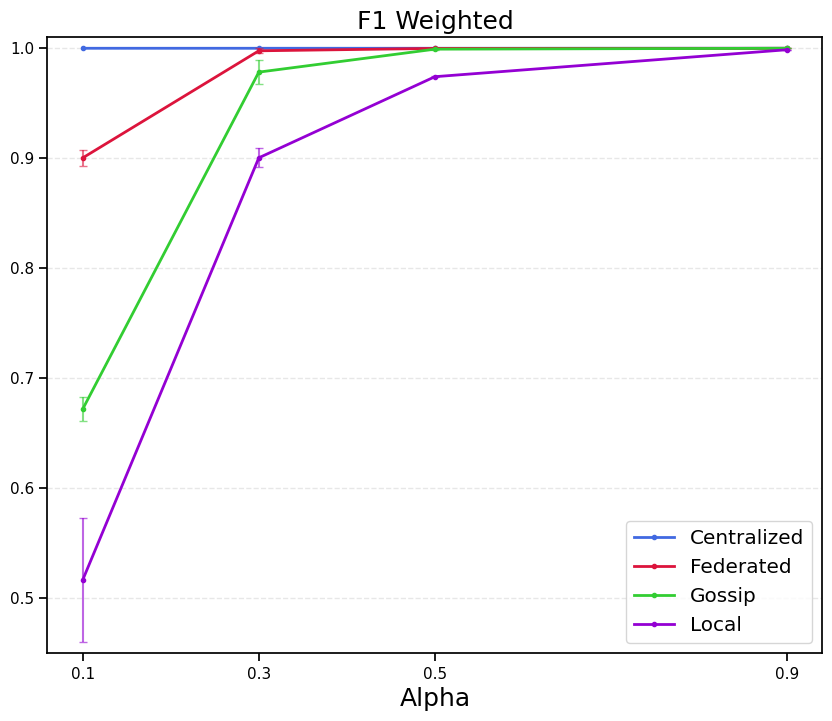

In [3]:
#new fed-centr-gossip-loc comparison

import numpy as np

data = []
lines_centr, lines_loc, lines_fed, lines_goss = [],[],[],[]
std_err_loc, std_err_fed, std_err_goss  = [],[],[]

nImproved, nSimple, nOwrt, nAgeW, nFisher = [],[],[],[],[]

with open('txts_comparison/f1centr.txt', 'r') as file:
    for line in file:
        lines_centr.append(eval(line.strip()))
file.close()
lines_loc, std_err_loc = read_txt("loc")
lines_fed, std_err_fed = read_txt("fed")
lines_goss, std_err_goss = read_txt("goss")

alphas = [0.1, 0.3, 0.5, 0.9]

f1_loc, f1_fed, f1_centr, f1_goss = [],[],[],[]


with sns.plotting_context("notebook"):
    colors = sns.color_palette("tab10", 3)
    fig, ax = plt.subplots(figsize=(10, 8), sharey=True)
    ax.set_title("F1 Weighted", fontsize=18)
    ax.set_xlabel("Alpha", fontsize=18)
    ax.set_xticks(alphas)
    ax.set_ylim(0.45, 1.01)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    for i in range(len(alphas)):
        f1_loc.append(lines_loc[i])
        f1_fed.append(lines_fed[i])
        f1_centr.append(lines_centr[i])
        f1_goss.append(lines_goss[i])
    plt.plot(
        alphas,
        f1_centr,
        label="Centralized",
        color="royalblue",
        linewidth=2,
        marker='.'
    )
    """ax.errorbar(
        alphas,
        f1_loc,
        yerr=[],
        fmt="none",
        ecolor="royalblue",
        capsize=3,
        alpha=0.6
    )"""

    plt.plot(
        alphas,
        f1_fed,
        label="Federated",
        color="crimson",
        linewidth=2,
        marker='.'
    )
    ax.errorbar(
        alphas,
        f1_fed,
        yerr=std_err_fed,
        fmt="none",
        ecolor="crimson",
        capsize=3,
        alpha=0.6
    )

    plt.plot(
        alphas,
        f1_goss,
        label="Gossip",
        color="limegreen",
        linewidth=2,
        marker='.'
    )
    ax.errorbar(
        alphas,
        f1_goss,
        yerr=std_err_goss,
        fmt="none",
        ecolor="limegreen",
        capsize=3,
        alpha=0.6
    )

    plt.plot(
        alphas,
        f1_loc,
        label="Local",
        color="darkviolet",
        linewidth=2,
        marker='.'
    )
    ax.errorbar(
        alphas,
        f1_loc,
        yerr=std_err_loc,
        fmt="none",
        ecolor="darkviolet",
        capsize=3,
        alpha=0.6
    )

    plt.legend(loc="lower right", fontsize="large")
    #plt.savefig(Path(path_folder) / "plot_comparison_trend.jpg")
    plt.show()
    plt.close()

In [4]:
#print(std_err)
print(std_err_fed)
print(std_err_goss)
print(std_err_loc)

[np.float64(0.007069700397509499), np.float64(0.0021805610209757464), np.float64(9.694844653795887e-06), np.float64(1.4851846224073206e-05)]
[np.float64(0.011106854988249008), np.float64(0.0106143453594697), np.float64(0.0003852523916007224), np.float64(4.0480796332786895e-06)]
[np.float64(0.05617955958741521), np.float64(0.008765132088040362), np.float64(0.000307269704690416), np.float64(4.76640301548814e-05)]


In [1]:
import numpy as np
def read_txt_dtst(aggr: str):

    nImproved, lines_macro, lines_w = [],[],[]
    std_err_m, std_err_w = [],[]

    with open(f'txt_CIC-TON/TON_Weighted_f1_{aggr}_k3_alpha1_10nodes.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    with open(f'txt_CIC-TON/TON_Weighted_f1_{aggr}_k3_alpha2_10nodes.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    with open(f'txt_CIC-TON/TON_Weighted_f1_{aggr}_k3_alpha3_10nodes.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    with open(f'txt_CIC-TON/TON_Weighted_f1_{aggr}_k3_alpha5_10nodes.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    return lines_macro, std_err_m

def read_txt_dtst2(aggr: str):

    nImproved, lines_macro, lines_w = [],[],[]
    std_err_m, std_err_w = [],[]

    with open(f'txt_CIC-TON/Weighted_f1_{aggr}_k3_alpha1_10nodes.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    with open(f'txt_CIC-TON/Weighted_f1_{aggr}_k3_alpha2_10nodes.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    with open(f'txt_CIC-TON/Weighted_f1_{aggr}_k3_alpha3_10nodes.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    with open(f'txt_CIC-TON/Weighted_f1_{aggr}_k3_alpha5_10nodes.txt', 'r') as file:
        for line in file:
            nImproved.append(eval(line.strip()))
        std_err_m.append(np.std(nImproved, ddof=1) / np.sqrt(np.size(nImproved)))
        lines_macro.append(sum(nImproved)/len(nImproved))
        nImproved.clear()
    file.close()

    return lines_macro, std_err_m

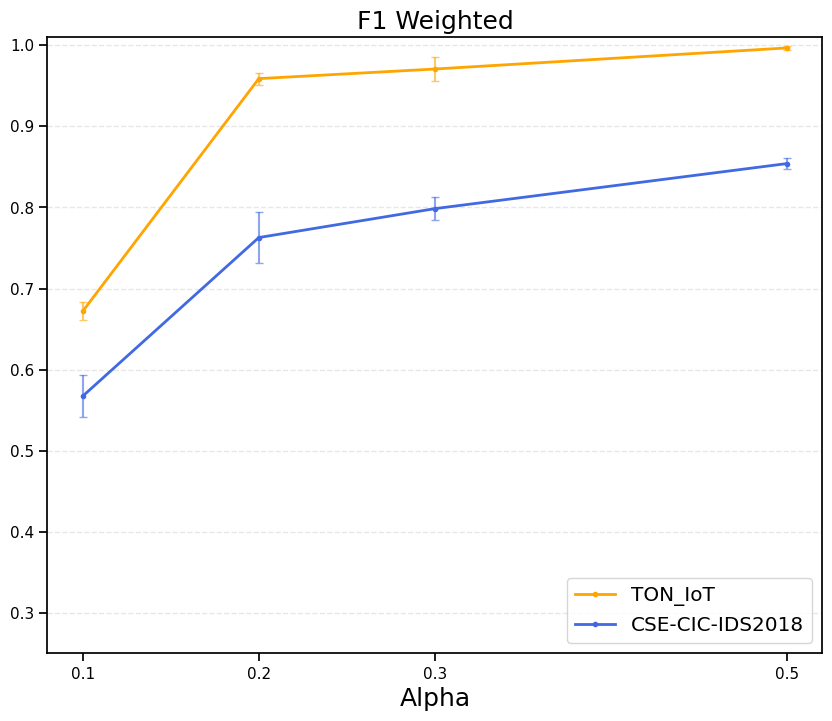

In [2]:
#TON_IOT CIC comparison
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = []
lines_TON, lines_CIC=[],[]
data = []
lines_centr, lines_loc, lines_fed, lines_goss_TON = [],[],[],[]
std_err_loc, std_err_fed, std_err_goss_TON  = [],[],[]

nImproved, nSimple, nOwrt, nAgeW, nFisher = [],[],[],[],[]

lines_goss_TON, std_err_goss_TON = read_txt_dtst("Improved_Overwrite")
lines_goss_CIC, std_err_goss_CIC = read_txt_dtst2("Improved_Overwrite")


#with open('f1_ImprovedOverwrite_TON_IOT.txt', 'r') as file:
#    for line in file:
#        lines_TON.append(eval(line.strip()))
#file.close()

#with open('f1_ImprovedOverwrite_CIC_IDS.txt', 'r') as file:
#    for line in file:
#        lines_CIC.append(eval(line.strip()))
#file.close()

#path_folder = Path(f"experiments/TON_IoT/{num_nodes}nTest{k}kAlpha0{alpha}_45UPDATES_5EPOCH") / f"{simulation_number}" / "testing_unified"
"""with sns.plotting_context("talk"):
    plt.figure(figsize=(10,8))
    plt.xlabel("Alpha")
    plt.ylabel("F1 Values")
    plt.xticks(alphas)
    #plt.yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
    f1_ton = []
    f1_cic = []
    for i in range(len(alphas)):
        f1_ton.append(lines_TON[i])
        f1_cic.append(lines_CIC[i])

    plt.plot(
        alphas,
        f1_ton,
        label="F1 TON_IOT dataset",
        color="royalblue",
        linewidth=2,
        marker='o'
    )
    plt.plot(
        alphas,
        f1_cic,
        label="F1 CIC-IDS-2018 dataset",
        color="orange",
        linewidth=2,
        marker='o'
    )

    plt.legend()
    #plt.savefig(Path(path_folder) / "plot_comparison_trend.jpg")
    plt.show()
    plt.close()"""
alphas = [0.1, 0.2, 0.3, 0.5]

f1_ton = []
f1_cic = []


with sns.plotting_context("notebook"):
    colors = sns.color_palette("tab10", 3)
    fig, ax = plt.subplots(figsize=(10, 8), sharey=True)
    ax.set_title("F1 Weighted", fontsize=18)
    ax.set_xlabel("Alpha", fontsize=18)
    ax.set_xticks(alphas)
    ax.set_ylim(0.25, 1.01)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    for i in range(len(alphas)):
        f1_ton.append(lines_goss_TON[i])
        f1_cic.append(lines_goss_CIC[i])
    

    plt.plot(
        alphas,
        f1_ton,
        label="TON_IoT",
        color="orange",
        linewidth=2,
        marker='.'
    )
    ax.errorbar(
        alphas,
        f1_ton,
        yerr=std_err_goss_TON,
        fmt="none",
        ecolor="orange",
        capsize=3,
        alpha=0.6
    )

    plt.plot(
        alphas,
        f1_cic,
        label="CSE-CIC-IDS2018",
        color="royalblue",
        linewidth=2,
        marker='.'
    )
    ax.errorbar(
        alphas,
        f1_cic,
        yerr=std_err_goss_CIC,
        fmt="none",
        ecolor="royalblue",
        capsize=3,
        alpha=0.6
    )

    plt.legend(loc="lower right", fontsize="large")
    #plt.savefig(Path(path_folder) / "plot_comparison_trend.jpg")
    plt.show()
    plt.close()

In [3]:
print(std_err_goss_TON)
print(std_err_goss_CIC)

[np.float64(0.011106854988249008), np.float64(0.007386418607393212), np.float64(0.015112033213086856), np.float64(0.0029115299063940843)]
[np.float64(0.02623717745860466), np.float64(0.03116678220326834), np.float64(0.014067895852286788), np.float64(0.007095433268544099)]
